# R programming
### Table of Contents
1. [Working with Arrays](#Working-with-Arrays-in-R-(Vectors))
2. [Generating a frequency distribution in R](#Generating-a-frequency-distribution-in-R)
3. [Working with an already developed frequency distribution](#Working-with-an-already-developed-frequency-distribution)
4. [Generate a histogram with a frequency distribution](#Generate-a-histogram-with-a-frequency-distribution)
5. [Generate a frequency polygon](#Generate-a-frequency-polygon)
6. [Generate a relative-frequency distribution](#Generate-a-relative-frequency-distribution)
7. [Generate a cumulative-frequency distribution](#Generate-a-cumulative-frequency-distribution)

## Working with Arrays in R (Vectors)

In [1]:
load('../Saves//Problem_2.2.Rdata')
cat(P2.2.data)

68 84 75 82 68 90 62 88 76 93 73 79 88 73 60 93 71 59 85 75 61 65 75 87 74 62 95 78 63 72 66 78 82 75 94 77 69 74 68 60 96 78 89 61 75 95 60 79 83 71 79 62 67 97 78 85 76 65 71 75 65 80 73 57 88 78 62 76 53 74 86 67 73 81 72 63 76 75 85 77

In [2]:
cat(sort(P2.2.data))

53 57 59 60 60 60 61 61 62 62 62 62 63 63 65 65 65 66 67 67 68 68 68 69 71 71 71 72 72 73 73 73 73 74 74 74 75 75 75 75 75 75 75 76 76 76 76 77 77 78 78 78 78 78 79 79 79 80 81 82 82 83 84 85 85 85 86 87 88 88 88 89 90 93 93 94 95 95 96 97

In [3]:
stem(P2.2.data)


  The decimal point is 1 digit(s) to the right of the |

  5 | 3
  5 | 79
  6 | 00011222233
  6 | 5556778889
  7 | 111223333444
  7 | 555555566667788888999
  8 | 012234
  8 | 555678889
  9 | 0334
  9 | 5567



In [4]:
max(P2.2.data)
min(P2.2.data)

[1] 97

[1] 53

---

## Generating a frequency distribution in R

### Method 1: By hand

In [3]:
load("../Saves//Problem_2.2.Rdata")
cat(sort(P2.2.data))

53 57 59 60 60 60 61 61 62 62 62 62 63 63 65 65 65 66 67 67 68 68 68 69 71 71 71 72 72 73 73 73 73 74 74 74 75 75 75 75 75 75 75 76 76 76 76 77 77 78 78 78 78 78 79 79 79 80 81 82 82 83 84 85 85 85 86 87 88 88 88 89 90 93 93 94 95 95 96 97

__Step 1:__ Determine the range

In [6]:
r<-range(P2.2.data)
cat("Range:", diff(r), "Lowest value:", r[1], "Largest value:", r[2], "\n")

Range: 44 Lowest value: 53 Largest value: 97 


__Step 2:__ Determine what the class boundaries will be. Since the data is a vector of integers, we will set the class boundaries to $0.5$.

In [7]:
cat("Lowest boundary:", (lower <- r[1]-.5), "\n")
cat("Upper boundary:", (upper <- r[2]+.5), "\n")
cat("New range:", (br <- upper-lower), "\n")
cat("Class interval:", (c <- br/9), "\n")
cat("Class boundaries:", (bins <- seq(lower, upper, by=c)))

Lowest boundary: 52.5 
Upper boundary: 97.5 
New range: 45 
Class interval: 5 
Class boundaries: 52.5 57.5 62.5 67.5 72.5 77.5 82.5 87.5 92.5 97.5

__Step 3:__ Determine the number of observations that fit into each bin.

In [8]:
Height <- cut(P2.2.data, bins)
fq.table <- table(Height)
transform(fq.table)

Height,Freq
<fct>,<int>
"(52.5,57.5]",2
"(57.5,62.5]",10
"(62.5,67.5]",8
"(67.5,72.5]",9
"(72.5,77.5]",20
"(77.5,82.5]",12
"(82.5,87.5]",7
"(87.5,92.5]",5
"(92.5,97.5]",7


In [9]:
transform(fq.table, Cum.Freq=cumsum(as.vector(fq.table)), Rel.Freq=round(prop.table(as.vector(fq.table))*100, 2), Cum.Rel.Freq=cumsum(round(prop.table(as.vector(fq.table))*100, 2)))

Height,Freq,Cum.Freq,Rel.Freq,Cum.Rel.Freq
<fct>,<int>,<int>,<dbl>,<dbl>
"(52.5,57.5]",2,2,2.50,2.50
"(57.5,62.5]",10,12,12.50,15.00
"(62.5,67.5]",8,20,10.00,25.00
"(67.5,72.5]",9,29,11.25,36.25
"(72.5,77.5]",20,49,25.00,61.25
"(77.5,82.5]",12,61,15.00,76.25
"(82.5,87.5]",7,68,8.75,85.00
"(87.5,92.5]",5,73,6.25,91.25
"(92.5,97.5]",7,80,8.75,100.00


### Method 2: Using the Histogram
The second method you can use for a quick frequency distribution is to use the historgram function which will generate a histogram plot as well.

In [10]:
(h <- hist(P2.2.data,plot=FALSE))
transform(table(cut(P2.2.data, h$breaks)))
h$counts/diff(h$breaks)

$breaks
 [1]  50  55  60  65  70  75  80  85  90  95 100

$counts
 [1]  1  5 11  7 19 15  8  7  5  2

$density
 [1] 0.0025 0.0125 0.0275 0.0175 0.0475 0.0375 0.0200 0.0175 0.0125 0.0050

$mids
 [1] 52.5 57.5 62.5 67.5 72.5 77.5 82.5 87.5 92.5 97.5

$xname
[1] "P2.2.data"

$equidist
[1] TRUE

attr(,"class")
[1] "histogram"

Var1,Freq
<fct>,<int>
"(50,55]",1
"(55,60]",5
"(60,65]",11
"(65,70]",7
"(70,75]",19
"(75,80]",15
"(80,85]",8
"(85,90]",7
"(90,95]",5


[1] 0.2 1.0 2.2 1.4 3.8 3.0 1.6 1.4 1.0 0.4

---

## Working with an already developed frequency distribution
If you already have a frequency distribution and you need to manually import it into R.

We will work with Table [2.1](01%20Text/03%20Frequency%20Distributions.ipynb#Table-2-1).

__Step 1:__ Create the class intervals as a vector of factors, and the frequencies as a vector of integers.

In [11]:
Height <- as.factor(c("60-62", "63-65", "66-68", "69-71", "72-74"))
Freq <- as.integer(c(5, 18, 42, 27, 8))
(fq.table <- data.frame(Height, Freq))

Height,Freq
<fct>,<int>
60-62,5
63-65,18
66-68,42
69-71,27
72-74,8


---

## Generate a histogram with a frequency distribution
You can generate a histogram using a frequency distribution like so (also working with Table [2.1](01%20Text/03%20Frequency%20Distributions.ipynb#Table-2-1)).

__Step 1:__ Calculate the breaks using the class intervals. (The interval size $c=3$). Since the last class interval ends at $74$, we will use $75$.

In [12]:
c <- 3
cat("Breaks:", (breaks <- seq(60, 75, by=3)))

Breaks: 60 63 66 69 72 75

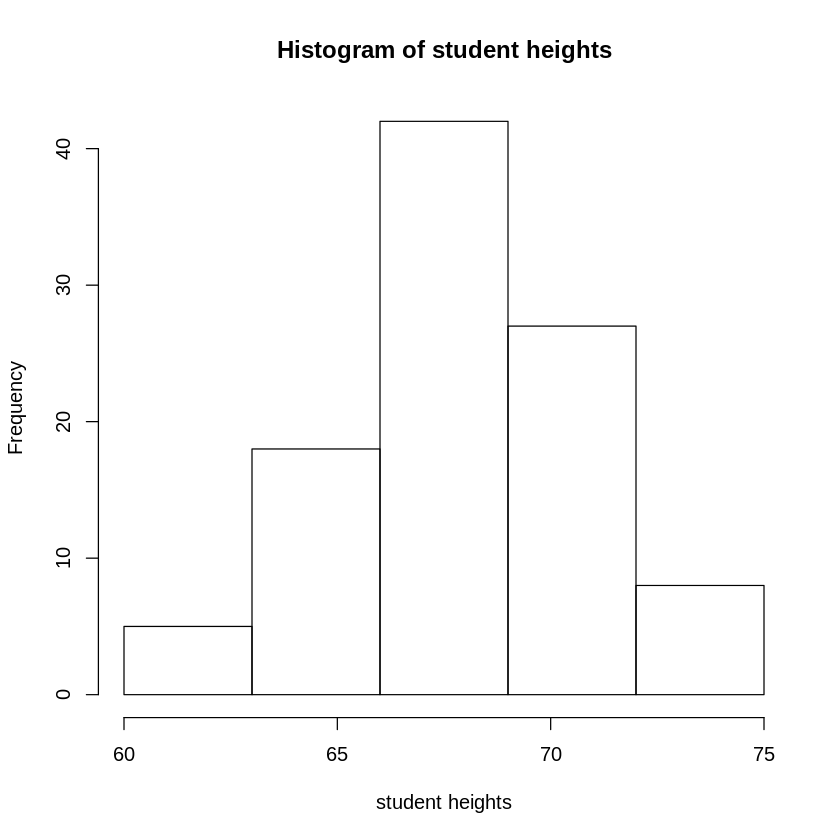

In [13]:
h <- list(breaks=breaks, counts=Freq, xname="student heights")
class(h) <- "histogram"
plot(h)

---

## Generate a frequency polygon

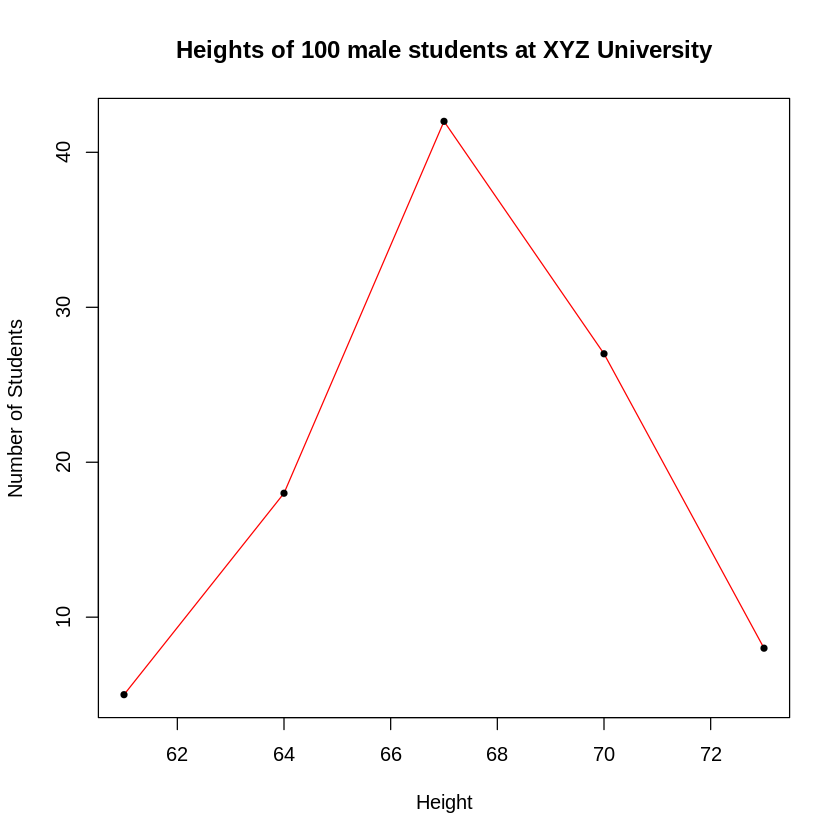

In [14]:
marks <- seq(61, 73, by=3)
plot(marks, h$counts, type="l", col="red", xlab="Height", ylab="Number of Students", main="Heights of 100 male students at XYZ University")
points(marks, h$counts, pch=20)

---

## Generate a relative-frequency distribution

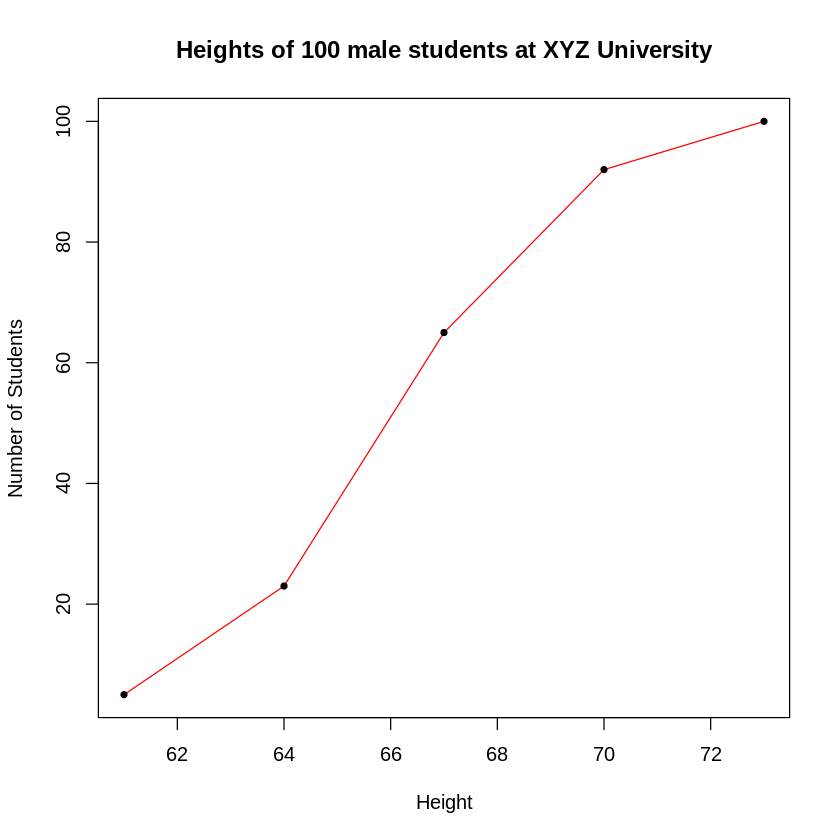

In [15]:
cumsum <- cumsum(h$counts)
plot(marks, cumsum, type="l", col="red", xlab="Height", ylab="Number of Students", main="Heights of 100 male students at XYZ University")
points(marks, cumsum, pch=20)

---

## Generate a cumulative-frequency distribution

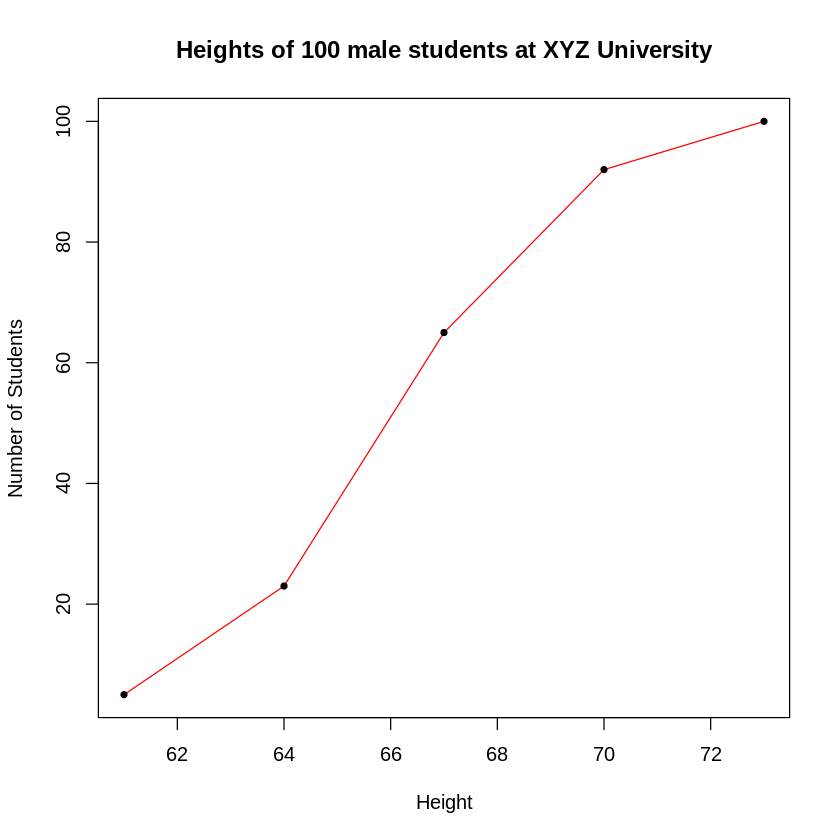

In [16]:
pct.cumsum <- round(cumsum(h$counts)/sum(h$counts)*100, 2)
plot(marks, pct.cumsum, type="l", col="red", xlab="Height", ylab="Number of Students", main="Heights of 100 male students at XYZ University")
points(marks, pct.cumsum, pch=20)

---